# Simple MNIST Neural Network

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
train_data = pd.read_csv('C:/Users/adria/OneDrive/University/Honours/STK 795/mnist_train.csv')
test_data = pd.read_csv('C:/Users/adria/OneDrive/University/Honours/STK 795/mnist_test.csv')

In [3]:
train_data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
train_data = np.array(train_data)
test_data = np.array(test_data)

np.random.shuffle(train_data)

# VALIDATION SET
val_data = train_data[:1000].T
Y_val = val_data[0]
X_val = val_data[1:, :] / 255.

# TRAIN SET
train_data = train_data[1000:].T
Y_train = train_data[0]
X_train = train_data[1:, :] / 255.

# TEST SET
test_data = test_data.T
Y_test = test_data[0]
X_test = test_data[1:, :] / 255.

In [5]:
def init_params():
    W1 = np.random.randn(64,784) * np.sqrt(2/784)
    W2 = np.random.randn(10,64) * np.sqrt(2/64)
    b1 = np.zeros((64,1))
    b2 = np.zeros((10,1))
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(Z, 0)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def ReLU_deriv(Z):
    return Z > 0
    
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * ReLU_deriv(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1    
    W2 = W2 - alpha * dW2  
    b2 = b2 - alpha * db2    
    return W1, b1, W2, b2

In [6]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X_train, Y_train, X_val, Y_val, alpha, iterations):
    W1, b1, W2, b2 = init_params()

    history_acc_train = []
    history_loss_train = []
    history_acc_val = []
    history_loss_val = []

    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X_train)

        train_loss = -np.mean(np.log(A2[Y_train, np.arange(Y_train.size)] + 1e-8))

        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X_train, Y_train)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2,dW1, db1, dW2, db2, alpha)

        # Training accuracy
        train_predictions = get_predictions(A2)
        train_accuracy = get_accuracy(train_predictions, Y_train)

        # Validation forward pass
        Z1_val, A1_val, Z2_val, A2_val = forward_prop(W1, b1, W2, b2, X_val)

        val_loss = -np.mean(np.log(A2_val[Y_val, np.arange(Y_val.size)] + 1e-8))
        val_predictions = get_predictions(A2_val)
        val_accuracy = get_accuracy(val_predictions, Y_val)

        history_acc_train.append(train_accuracy)
        history_loss_train.append(train_loss)
        history_acc_val.append(val_accuracy)
        history_loss_val.append(val_loss)

    print(f"Final iteration: {iterations}")
    print(f"Final train accuracy: {train_accuracy:.4f}")
    print(f"Final validation accuracy: {val_accuracy:.4f}")
    print(f"Final train loss: {train_loss:.4f}")
    print(f"Final validation loss: {val_loss:.4f}")

    return(W1, b1, W2, b2,
           history_acc_train,
           history_loss_train,
           history_acc_val,
           history_loss_val 
          )

Final iteration: 2000
Final train accuracy: 0.9529
Final validation accuracy: 0.9430
Final train loss: 0.1707
Final validation loss: 0.2214


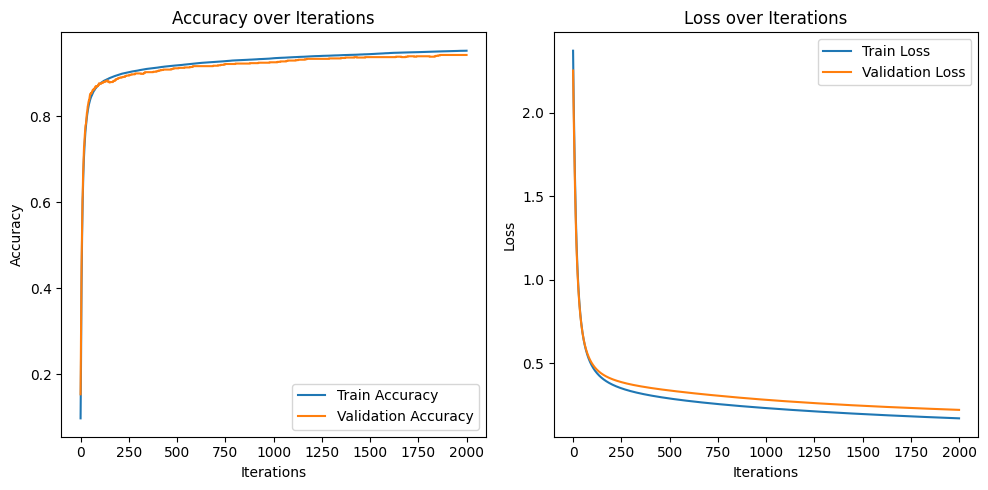

In [7]:
W1, b1, W2, b2, history_acc_train, history_loss_train, history_acc_val, history_loss_val = gradient_descent(X_train, Y_train, 
                                                                                                            X_val, Y_val, 
                                                                                                            0.1, 2000)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(history_acc_train, label = 'Train Accuracy')
axs[0].plot(history_acc_val, label = 'Validation Accuracy')
axs[0].set_title('Accuracy over Iterations')
axs[0].set_xlabel('Iterations')
axs[0].set_ylabel('Accuracy')
axs[0].legend()

axs[1].plot(history_loss_train, label = 'Train Loss')
axs[1].plot(history_loss_val, label = 'Validation Loss')
axs[1].set_title('Loss over Iterations')
axs[1].set_xlabel('Iterations')
axs[1].set_ylabel('Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

In [8]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [1]
Label:  1


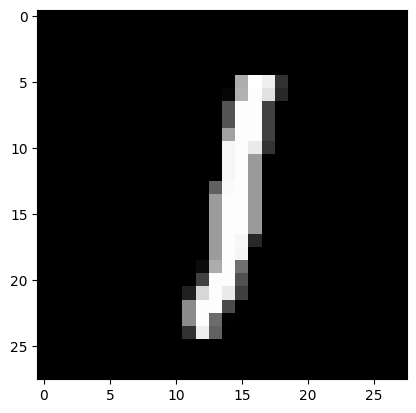

Prediction:  [6]
Label:  6


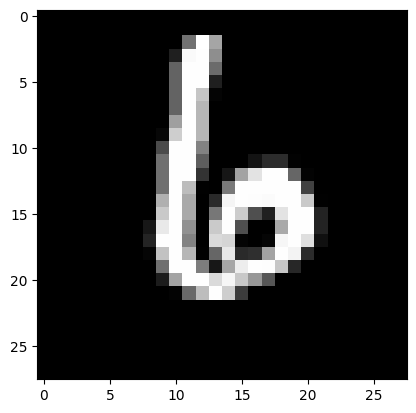

Prediction:  [0]
Label:  0


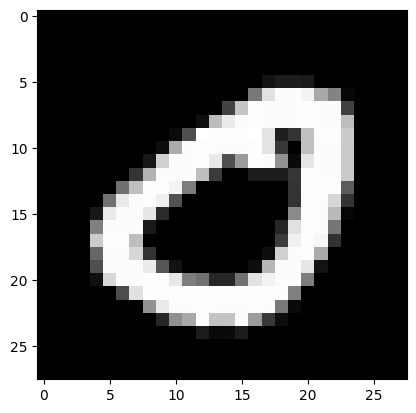

Prediction:  [0]
Label:  0


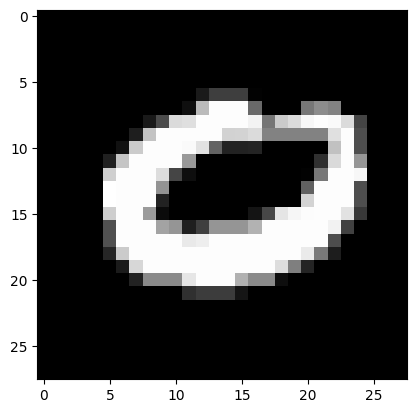

In [9]:
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)

In [11]:
test_predictions = make_predictions(X_test, W1, b1, W2, b2)
get_accuracy(test_predictions, Y_test)

np.float64(0.9494)